# Preparing Meteorological Inputs #

This section shows a complete example of the current NetCDF-based meteorological workflow in `pycequeau`.

The workflow assumes that the project already contains a `meteo/ERA` folder with prepared NetCDF files for the basin.

1. create the `Basin` object
2. derive an additional meteorological variable when needed
3. load the NetCDF meteorological files
4. inspect missing values
5. interpolate the meteorological fields
6. construct the CEQUEAU meteorological grid
7. save the resulting NetCDF file


In [11]:
import os
import matplotlib.pyplot as plt

from pycequeau.physiographic import Basin
from pycequeau.meteo import MeteoCalculator, NetCDFMeteo
from pycequeau.core.netcdf import intermidiate_interpolation

## Expected content of the ERA folder

The `ERA` folder is expected to contain NetCDF files prepared for the basin, usually with one meteorological variable per file. The ERA folder should be located in the following path `path/to/your/project/meteo/ERA`

The file names themselves do not matter. What matters for `pycequeau` is that each file contains a supported variable name and valid units metadata.

For the current example project, the files in the folder look like this:

| File name | Variable name | Units in this example | Other accepted units |
| --- | --- | --- | --- |
| `era5_10m-wind-speed_daily.nc` | `wind` | `m s-1` | `km h-1` |
| `era5_2m-dewpoint-temperature_daily.nc` | `d2m` | `K` | `C` |
| `era5_2m-temperature_daily_max.nc` | `tasmax` | `K` | `C` |
| `era5_2m-temperature_daily_min.nc` | `tasmin` | `K` | `C` |
| `era5_surface-solar-radiation-downwards_daily.nc` | `ssrd` | `J m-2` | `MJ m-2 d-1`<br>`MJ m-2`<br>`J m-2 d-1`<br>`W m-2` |
| `era5_surface-thermal-radiation-downwards_daily.nc` | `strd` | `J m-2` | `MJ m-2 d-1`<br>`MJ m-2`<br>`J m-2 d-1`<br>`W m-2` |
| `era5_total-cloud-cover_daily.nc` | `tcc` | `0-1` | `fraction`<br>`1`<br>`%`<br>`percent` |
| `era5_total-precipitation_daily.nc` | `tp` | `m` | `mm d-1`<br>`mm`<br>`m d-1`<br>`kg m-2 s-1` |
| `saturated_vapor_pressure.nc` | `vp` | `mmHg` | `Pa`<br>`kPa` |

Most of these files come from prepared ERA5 products aggregated to the daily time step. In this workflow, wind speed and vapor pressure are obtained with the meteorological calculators before the complete meteorological dataset is loaded.

In the example below, `saturated_vapor_pressure.nc` is created from `d2m` with `MeteoCalculator.create_variable_file(...)`. The wind-speed file follows the same idea, using the meteorological calculators to derive `wind` from the original wind components. For the calculator API reference, see [the meteorological calculators module](../api/pycequeau.meteo.calculators.rst).


## Project configuration

Set the project folder, the basin name, and the raster files used to initialize the basin.

In [ ]:
project_folder = r"path/to/your/project/"
files_list = ["DEM.tif", # DEM tif file
                "FAC.tif", #Flow accumulation tif file
                "LCF.tif", # Land conver tif file
                "Watershed.tif", # Watershed tif file
                "CAT.tif" #Sub basins tif file
                ]
basin_name = "Margarite"

bassin_versant_file = os.path.join(
    project_folder,
    "results",
    "bassinVersant.mat",
)
meteo_folder = os.path.join(project_folder, "meteo", "ERA")

## Create the basin object

The basin object is required to project and export the meteorological data to the CEQUEAU grid.

In [13]:
basin = Basin(
    project_folder,
    basin_name,
    files_list,
    bassin_versant_file,
)

## Load the NetCDF meteorological inputs

Once the folder is ready, load the NetCDF meteorological files with `NetCDFMeteo.load_from_netcdf`.

In [14]:
meteo_stations = NetCDFMeteo.load_from_netcdf(
    basin,
    meteo_folder,
)

meteo_stations.ds

<xarray.Dataset> Size: 11MB
Dimensions:      (lat: 41, lon: 21, time: 365)
Coordinates:
  * lat          (lat) float64 328B 40.0 40.25 40.5 40.75 ... 49.5 49.75 50.0
  * lon          (lon) float64 168B -70.0 -69.75 -69.5 ... -65.5 -65.25 -65.0
  * time         (time) datetime64[ns] 3kB 2023-01-01 2023-01-02 ... 2023-12-31
Data variables:
    vitesseVent  (time, lat, lon) float32 1MB 28.55 28.45 28.2 ... 20.39 20.99
    d2m          (time, lat, lon) float32 1MB 12.06 12.06 ... -7.709 -7.567
    tMax         (time, lat, lon) float32 1MB 16.69 16.64 ... -1.797 -1.594
    tMin         (time, lat, lon) float32 1MB 11.38 11.34 11.06 ... -5.42 -5.135
    rayonnement  (time, lat, lon) float32 1MB ...
    longwaveRad  (time, lat, lon) float32 1MB ...
    nebulosite   (time, lat, lon) float32 1MB ...
    pTot         (time, lat, lon) float32 1MB ...
    pression     (time, lat, lon) float32 1MB ...
Attributes:
    source_dataset:           era5
    source_variables:         10m_u_component_of_wind, 10m_v_component_of_wind
    processing_level:         daily
    daily_aggregation:        daily_vector_magnitude_from_daily_mean_components
    daily_conversion_method:  sfcWind = sqrt(u10^2 + v10^2)

## Downscale the meteorological grid when needed

In some cases, the meteorological grid is so coarse that the basin falls within a single source pixel. In that situation, the interpolation to the CEQUEAU grid cannot be performed in a meaningful way.

The `intermidiate_interpolation` step can be used to downscale the meteorological input first, so that several source points are available before interpolating to the CEQUEAU grid.

In [15]:
meteo_stations.ds = intermidiate_interpolation(meteo_stations.ds, 5)
meteo_stations.ds

<xarray.Dataset> Size: 263MB
Dimensions:      (time: 365, lat: 200, lon: 100)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2023-01-01 2023-01-02 ... 2023-12-31
  * lat          (lat) float64 2kB 40.0 40.05 40.1 40.15 ... 49.85 49.9 49.95
  * lon          (lon) float64 800B -70.0 -69.95 -69.9 ... -65.15 -65.1 -65.05
Data variables:
    vitesseVent  (time, lat, lon) float32 29MB 28.55 28.55 28.55 ... 20.99 20.99
    d2m          (time, lat, lon) float32 29MB 12.06 12.06 ... -7.567 -7.567
    tMax         (time, lat, lon) float32 29MB 16.69 16.69 ... -1.594 -1.594
    tMin         (time, lat, lon) float32 29MB 11.38 11.38 ... -5.135 -5.135
    rayonnement  (time, lat, lon) float32 29MB 7.048 7.048 7.048 ... 4.117 4.117
    longwaveRad  (time, lat, lon) float32 29MB 29.97 29.97 29.97 ... 19.93 19.93
    nebulosite   (time, lat, lon) float32 29MB 0.6492 0.6492 ... 0.6049 0.6049
    pTot         (time, lat, lon) float32 29MB 17.02 17.02 ... 0.3147 0.3147
    pression     (time, lat, lon) float32 29MB 10.56 10.56 10.56 ... 2.412 2.412
Attributes:
    source_dataset:           era5
    source_variables:         10m_u_component_of_wind, 10m_v_component_of_wind
    processing_level:         daily
    daily_aggregation:        daily_vector_magnitude_from_daily_mean_components
    daily_conversion_method:  sfcWind = sqrt(u10^2 + v10^2)

## Interpolate the meteorological fields

This example uses the `nearest` method.

In [16]:
interpolated = meteo_stations.interpolation("nearest")
interpolated

<xarray.Dataset> Size: 26MB
Dimensions:      (time: 365, j: 40, i: 49)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2023-01-01 2023-01-02 ... 2023-12-31
  * j            (j) int16 80B 49 48 47 46 45 44 43 42 ... 16 15 14 13 12 11 10
  * i            (i) int16 98B 10 11 12 13 14 15 16 17 ... 52 53 54 55 56 57 58
Data variables:
    vitesseVent  (time, j, i) float32 3MB nan nan nan nan ... nan nan nan nan
    d2m          (time, j, i) float32 3MB nan nan nan nan ... nan nan nan nan
    tMax         (time, j, i) float32 3MB nan nan nan nan ... nan nan nan nan
    tMin         (time, j, i) float32 3MB nan nan nan nan ... nan nan nan nan
    rayonnement  (time, j, i) float32 3MB nan nan nan nan ... nan nan nan nan
    longwaveRad  (time, j, i) float32 3MB nan nan nan nan ... nan nan nan nan
    nebulosite   (time, j, i) float32 3MB nan nan nan nan ... nan nan nan nan
    pTot         (time, j, i) float32 3MB nan nan nan nan ... nan nan nan nan
    pression     (time, j, i) float32 3MB nan nan nan nan ... nan nan nan nan
    CE           (j, i) float16 4kB nan nan nan nan nan ... 33.0 nan nan nan nan
Attributes:
    source_dataset:           era5
    source_variables:         10m_u_component_of_wind, 10m_v_component_of_wind
    processing_level:         daily
    daily_aggregation:        daily_vector_magnitude_from_daily_mean_components
    daily_conversion_method:  sfcWind = sqrt(u10^2 + v10^2)
    interpolated:             Interpolated using xarray.Dataset.interp with m...

## Build the CEQUEAU grid

After interpolation, the fields can be reorganized into the CEQUEAU meteorological grid.

In [17]:
grid_cequeau = meteo_stations.cequeau_grid(interpolated, basin)
grid_cequeau

<xarray.Dataset> Size: 14MB
Dimensions:      (CEid: 1052, pasTemp: 365)
Coordinates:
  * CEid         (CEid) int32 4kB 1 2 3 4 5 6 ... 1047 1048 1049 1050 1051 1052
  * pasTemp      (pasTemp) float32 1kB 7.389e+05 7.389e+05 ... 7.393e+05
Data variables:
    vitesseVent  (pasTemp, CEid) float32 2MB 8.566 8.566 8.566 ... 13.79 13.79
    d2m          (pasTemp, CEid) float32 2MB -0.9576 -0.9576 ... -10.33 -10.33
    tMax         (pasTemp, CEid) float32 2MB 1.234 1.234 1.234 ... -6.68 -6.68
    tMin         (pasTemp, CEid) float32 2MB -0.9955 -0.9955 ... -11.58 -11.58
    rayonnement  (pasTemp, CEid) float32 2MB 2.401 2.401 2.401 ... 4.81 4.81
    longwaveRad  (pasTemp, CEid) float32 2MB 25.93 25.93 25.93 ... 18.86 18.86
    nebulosite   (pasTemp, CEid) float32 2MB 0.9681 0.9681 ... 0.8501 0.8501
    pTot         (pasTemp, CEid) float32 2MB 4.324 4.324 4.324 ... 0.1087 0.1087
    pression     (pasTemp, CEid) float32 2MB 4.233 4.233 4.233 ... 1.891 1.891

## Plot a sample day

A quick plot can be useful to visually inspect a few interpolated meteorological fields before exporting the CEQUEAU file.

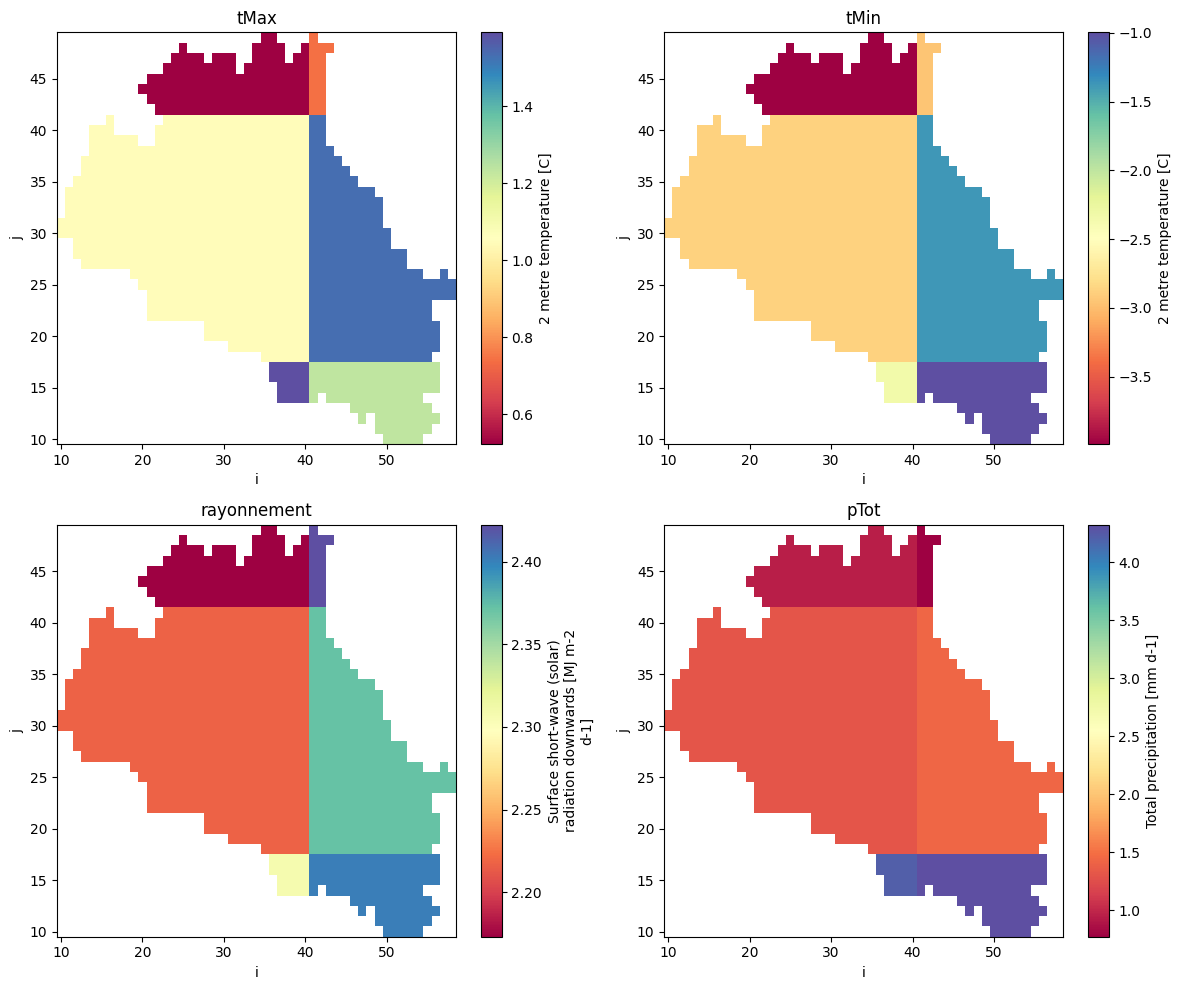

In [18]:
plot_ds = interpolated.isel(time=0)

fig, axes = plt.subplots(
    ncols=2,
    nrows=2,
    figsize=(12, 10),
)

plot_ds["tMax"].plot(ax=axes[0, 0], cmap="Spectral")
plot_ds["tMin"].plot(ax=axes[0, 1], cmap="Spectral")
plot_ds["rayonnement"].plot(ax=axes[1, 0], cmap="Spectral")
plot_ds["pTot"].plot(ax=axes[1, 1], cmap="Spectral")

axes[0, 0].set_title("tMax")
axes[0, 1].set_title("tMin")
axes[1, 0].set_title("rayonnement")
axes[1, 1].set_title("pTot")

plt.tight_layout()

## Save the final NetCDF file

The resulting CEQUEAU-ready meteorological dataset can then be written to disk.

In [19]:
output_file = os.path.join(project_folder, "meteo", "meteo_cequeau.nc")
grid_cequeau.to_netcdf(output_file)
# output_file